The project aims to examine patterns, relationships, and trends within the dataset to understand how factors such as work environment, workload, work-life balance, and communication influence employees psychological well-being.The goal is to generate meaningful insights that can help organizations and policymakers to understand better the challenges associated with remote work and develop strategies to improve employee well-being and workplace productivity.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

1.Data Loading and Initial Overview 
Loading the edited file since original file had no missing values so created one with some missing values.

In [3]:
rw=pd.read_csv(("C:/Users/User/Downloads/edited remote work.csv"))

In [4]:
rw

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32.0,Non-binary,HR,Healthcare,13.0,Hybrid,47.0,7.0,2.0,Medium,Depression,No,Decrease,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40.0,Female,Data Scientist,IT,3.0,Remote,52.0,4.0,1.0,Medium,Anxiety,No,Increase,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59.0,Non-binary,Software Engineer,Education,22.0,Hybrid,46.0,NaN,5.0,Medium,Anxiety,No,No Change,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27.0,Male,Software Engineer,Finance,20.0,Onsite,32.0,8.0,4.0,High,Depression,Yes,Increase,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49.0,Male,Sales,Consulting,32.0,Onsite,35.0,12.0,2.0,High,NaN,Yes,Decrease,Unsatisfied,3,Weekly,Average,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,EMP2496,31.0,Male,Data Scientist,IT,20.0,Onsite,48.0,0.0,1.0,High,Anxiety,Yes,Increase,Unsatisfied,3,Daily,Good,Asia
2496,EMP2497,55.0,Prefer not to say,Software Engineer,Education,15.0,Onsite,41.0,15.0,3.0,Low,Anxiety,No,No Change,Unsatisfied,5,Weekly,Good,Oceania
2497,EMP2498,47.0,Male,Project Manager,IT,19.0,Onsite,27.0,7.0,3.0,Low,Burnout,Yes,Increase,Neutral,4,Weekly,Average,South America
2498,EMP2499,56.0,Female,Data Scientist,Healthcare,18.0,Remote,21.0,13.0,2.0,Medium,Depression,No,Increase,Neutral,3,Daily,Good,Oceania


In [5]:
#Number of rows and columns
print("shape of the dataset: ",rw.shape)

shape of the dataset:  (2500, 19)


In [6]:
#data type of columns
print("data type of each column:\n")
rw.dtypes

data type of each column:



Employee_ID                           object
Age                                  float64
Gender                                object
Job_Role                              object
Industry                              object
Years_of_Experience                  float64
Work_Location                         object
Hours_Worked_Per_Week                float64
Number_of_Virtual_Meetings           float64
Work_Life_Balance_Rating             float64
Stress_Level                          object
Mental_Health_Condition               object
Access_to_Mental_Health_Resources     object
Productivity_Change                   object
Satisfaction_with_Remote_Work         object
Company_Support_for_Remote_Work        int64
Physical_Activity                     object
Sleep_Quality                         object
Region                                object
dtype: object

Initial Observation:

In [7]:
rw.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32.0,Non-binary,HR,Healthcare,13.0,Hybrid,47.0,7.0,2.0,Medium,Depression,No,Decrease,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40.0,Female,Data Scientist,IT,3.0,Remote,52.0,4.0,1.0,Medium,Anxiety,No,Increase,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59.0,Non-binary,Software Engineer,Education,22.0,Hybrid,46.0,NaN,5.0,Medium,Anxiety,No,No Change,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27.0,Male,Software Engineer,Finance,20.0,Onsite,32.0,8.0,4.0,High,Depression,Yes,Increase,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49.0,Male,Sales,Consulting,32.0,Onsite,35.0,12.0,2.0,High,NaN,Yes,Decrease,Unsatisfied,3,Weekly,Average,North America


In [8]:
rw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Employee_ID                        2500 non-null   object 
 1   Age                                2498 non-null   float64
 2   Gender                             2500 non-null   object 
 3   Job_Role                           2498 non-null   object 
 4   Industry                           2498 non-null   object 
 5   Years_of_Experience                2497 non-null   float64
 6   Work_Location                      2497 non-null   object 
 7   Hours_Worked_Per_Week              2494 non-null   float64
 8   Number_of_Virtual_Meetings         2496 non-null   float64
 9   Work_Life_Balance_Rating           2498 non-null   float64
 10  Stress_Level                       2500 non-null   object 
 11  Mental_Health_Condition            1905 non-null   objec

In [9]:
rw.describe()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Company_Support_for_Remote_Work
count,2498.000000,2497.000000,2494.000000,2496.000000,2498.000000,2500.000000
mean,41.104484,17.723268,39.471933,7.602564,2.992394,3.046400
std,11.295707,9.993944,11.829202,4.619717,1.393223,1.404933
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000
50%,41.000000,18.000000,39.000000,8.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000


In [10]:
rw.isnull().sum()

Employee_ID                            0
Age                                    2
Gender                                 0
Job_Role                               2
Industry                               2
Years_of_Experience                    3
Work_Location                          3
Hours_Worked_Per_Week                  6
Number_of_Virtual_Meetings             4
Work_Life_Balance_Rating               2
Stress_Level                           0
Mental_Health_Condition              595
Access_to_Mental_Health_Resources      3
Productivity_Change                    1
Satisfaction_with_Remote_Work          3
Company_Support_for_Remote_Work        0
Physical_Activity                    833
Sleep_Quality                          0
Region                                 0
dtype: int64

2.1 Handling missing numerical values with mean:

In [11]:
rw['Age']=rw['Age'].fillna(rw['Age'].mean())
rw['Years_of_Experience']=rw['Years_of_Experience'].fillna(rw['Years_of_Experience'].mean())
rw['Hours_Worked_Per_Week']=rw['Hours_Worked_Per_Week'].fillna(rw['Hours_Worked_Per_Week'].mean())
rw['Number_of_Virtual_Meetings']=rw['Number_of_Virtual_Meetings'].fillna(rw['Number_of_Virtual_Meetings'].mean())
rw['Work_Life_Balance_Rating']=rw['Work_Life_Balance_Rating'].fillna(rw['Work_Life_Balance_Rating'].mean())

2.11 Handling missing categorical values with mode:

In [12]:
rw['Job_Role']=rw['Job_Role'].fillna(rw['Job_Role'].mode()[0])
rw['Industry']=rw['Industry'].fillna(rw['Industry'].mode()[0])
rw['Work_Location']=rw['Work_Location'].fillna(rw['Work_Location'].mode()[0])
rw['Mental_Health_Condition']=rw['Mental_Health_Condition'].fillna(rw['Mental_Health_Condition'].mode()[0])
rw['Access_to_Mental_Health_Resources']=rw['Access_to_Mental_Health_Resources'].fillna(rw['Access_to_Mental_Health_Resources'].mode()[0])
rw['Productivity_Change']=rw['Productivity_Change'].fillna(rw['Productivity_Change'].mode()[0])
rw['Satisfaction_with_Remote_Work']=rw['Satisfaction_with_Remote_Work'].fillna(rw['Satisfaction_with_Remote_Work'].mode()[0])
rw['Physical_Activity']=rw['Physical_Activity'].fillna(rw['Physical_Activity'].mode()[0])

In [13]:
rw.isnull().sum()

Employee_ID                          0
Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
Region                               0
dtype: int64

2.2 Removing Duplicates

In [14]:
rw.duplicated().sum()

np.int64(1)

In [15]:
rw.drop_duplicates()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32.0,Non-binary,HR,Healthcare,13.0,Hybrid,47.0,7.000000,2.0,Medium,Depression,No,Decrease,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40.0,Female,Data Scientist,IT,3.0,Remote,52.0,4.000000,1.0,Medium,Anxiety,No,Increase,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59.0,Non-binary,Software Engineer,Education,22.0,Hybrid,46.0,7.602564,5.0,Medium,Anxiety,No,No Change,Unsatisfied,5,Weekly,Poor,North America
3,EMP0004,27.0,Male,Software Engineer,Finance,20.0,Onsite,32.0,8.000000,4.0,High,Depression,Yes,Increase,Unsatisfied,3,Weekly,Poor,Europe
4,EMP0005,49.0,Male,Sales,Consulting,32.0,Onsite,35.0,12.000000,2.0,High,Burnout,Yes,Decrease,Unsatisfied,3,Weekly,Average,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2494,EMP2495,45.0,Prefer not to say,Project Manager,Education,16.0,Onsite,42.0,0.000000,2.0,Low,Depression,No,No Change,Satisfied,4,Daily,Good,South America
2495,EMP2496,31.0,Male,Data Scientist,IT,20.0,Onsite,48.0,0.000000,1.0,High,Anxiety,Yes,Increase,Unsatisfied,3,Daily,Good,Asia
2496,EMP2497,55.0,Prefer not to say,Software Engineer,Education,15.0,Onsite,41.0,15.000000,3.0,Low,Anxiety,No,No Change,Unsatisfied,5,Weekly,Good,Oceania
2497,EMP2498,47.0,Male,Project Manager,IT,19.0,Onsite,27.0,7.000000,3.0,Low,Burnout,Yes,Increase,Neutral,4,Weekly,Average,South America


2.3 Correcting Data Type

In [16]:
rw['Age']=rw['Age'].astype(int)
rw['Years_of_Experience']=rw['Years_of_Experience'].astype(int)
rw['Number_of_Virtual_Meetings']=rw['Number_of_Virtual_Meetings'].astype(int)
rw['Work_Life_Balance_Rating']=rw['Work_Life_Balance_Rating'].astype(int)

2.4 Creating Derived Column

In [17]:
rw['work load by age'] = rw['Hours_Worked_Per_Week']/rw['Age']

2.4 Filtering Data

In [18]:
rw['high work']=rw['Number_of_Virtual_Meetings']>=8

2.4 Aggregating Data

In [19]:
rw.groupby('Work_Location')['Industry'].unique()

Work_Location
Hybrid    [Healthcare, Education, IT, Consulting, Manufa...
Onsite    [Finance, Consulting, Manufacturing, Education...
Remote    [IT, Finance, Consulting, Retail, Healthcare, ...
Name: Industry, dtype: object

3.Exploratory Data Analysis (EDA) 
simplifies data by descriptive and exploratory analysis to uncover patterns and trends Univariate, bivariate, and multivariate analysis,Using groupby, pivot tables and correlation analysis by Including statistical summaries to support findings generated.

3.1 Univariate, bivariate, and multivariate analysis

In [20]:
#univariate
df_counts = rw['Work_Location'].value_counts().reset_index()
df_counts

,Work_Location,count
0,Remote,884
1,Hybrid,839
2,Onsite,777


FINDINGS:
*The distribution is fairly balanced, with no extreme dominance by any single work type.
*Remote work has the highest number of employees.
*Both remote and hybrid models are widely adopted, showing flexibility in work arrangements.

In [21]:
#bivariate
df_group=rw.groupby('Age')['Hours_Worked_Per_Week'].mean().reset_index()
df_group

,Age,Hours_Worked_Per_Week
0,22,39.305085
1,23,39.191176
2,24,38.160494
3,25,38.391304
4,26,39.981481
5,27,40.068966
6,28,41.432836
7,29,38.745098
8,30,41.171429
9,31,39.509434


FINDING:
*The average working hours across all age groups remain fairly consistent, mostly between 38 to 41 hours per week.
*Mid-career and experienced employees may have higher responsibilities, leading to slightly longer working hours.    

In [22]:
#multivariate
rw[['Job_Role','Work_Location','Stress_Level']].head()

,Job_Role,Work_Location,Stress_Level
0,HR,Hybrid,Medium
1,Data Scientist,Remote,Medium
2,Software Engineer,Hybrid,Medium
3,Software Engineer,Onsite,High
4,Sales,Onsite,High


FINDING:
*Software Engineers show both medium and high stress levels, especially in onsite roles.
*Sales roles exhibit high stress levels, particularly in onsite work.
*HR and Data Scientist roles show moderate (medium) stress levels.
*Onsite roles (Software Engineer, Sales) are associated with higher stress levels.
*Remote and Hybrid roles (HR, Data Scientist, Software Engineer) show moderate stress.

3.2  Groupby,Pivot tables and Correlation Analysis

In [23]:
# Average work hour by industry
df_avg=rw.groupby('Industry')['Hours_Worked_Per_Week'].mean().reset_index()
df_avg

,Industry,Hours_Worked_Per_Week
0,Consulting,39.111111
1,Education,39.147331
2,Finance,39.076726
3,Healthcare,39.855978
4,IT,40.028456
5,Manufacturing,39.773357
6,Retail,39.312000


FINDING:
*There is no major difference in working hours across industries.
*IT (40.03 hrs) and Healthcare (39.86 hrs) have the highest average working hours.

In [24]:
#pivot table 
pd.pivot_table(rw,values='Stress_Level',index='Work_Location',columns='Gender', aggfunc='max')

Gender,Female,Male,Non-binary,Prefer not to say
Work_Location,,,,
Hybrid,Medium,Medium,Medium,Medium
Onsite,Medium,Medium,Medium,Medium
Remote,Medium,Medium,Medium,Medium


FINDING:
The pivot table indicates that the maximum stress level across all work locations and gender groups is “Medium”.
This suggests a consistent level of stress among employees, with no significant differences based on gender or work environment.

In [25]:
#correlation analysis
corr = rw.corr(numeric_only=True)
print(corr)

                                      Age  Years_of_Experience  \
Age                              1.000000             0.009078   
Years_of_Experience              0.009078             1.000000   
Hours_Worked_Per_Week            0.005324            -0.024019   
Number_of_Virtual_Meetings       0.025781             0.015714   
Work_Life_Balance_Rating        -0.005516            -0.017741   
Company_Support_for_Remote_Work  0.025374             0.003998   
work load by age                -0.674086            -0.031082   
high work                        0.028203             0.017976   

                                 Hours_Worked_Per_Week  \
Age                                           0.005324   
Years_of_Experience                          -0.024019   
Hours_Worked_Per_Week                         1.000000   
Number_of_Virtual_Meetings                    0.011345   
Work_Life_Balance_Rating                     -0.007294   
Company_Support_for_Remote_Work               0.009575   

FINDING:
*The correlation analysis reveals a strong positive relationship between the number of virtual meetings and high workload, indicating that frequent meetings significantly increase work pressure.
*A strong negative relationship between age and workload indicates that younger employees tend to experience higher workload compared to older employees.

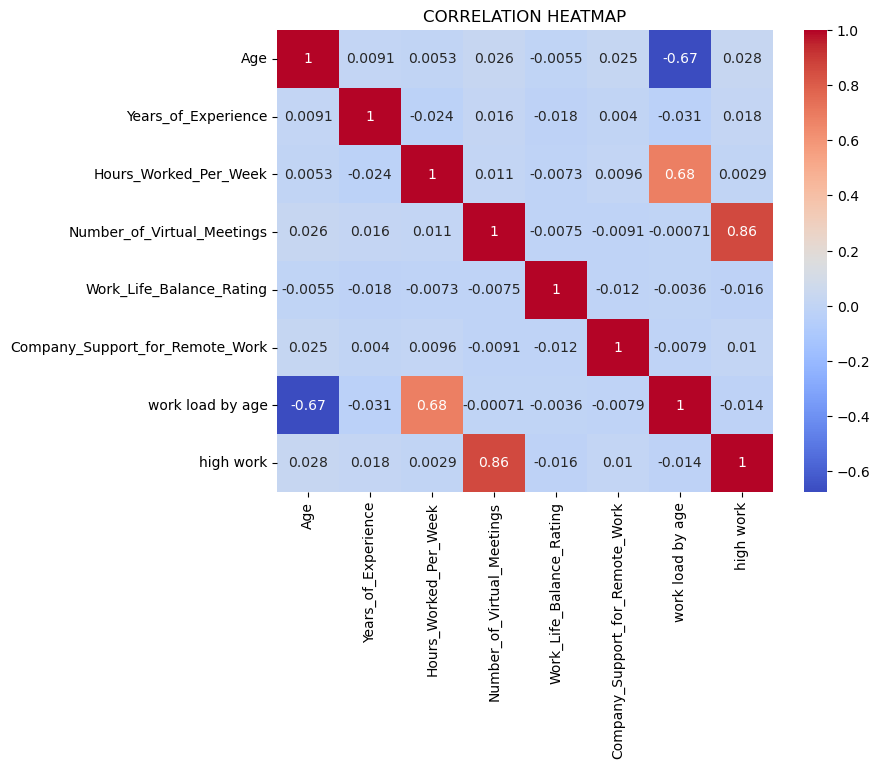

In [26]:
#correlation map
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("CORRELATION HEATMAP")
plt.show()

FINDING:
Strong positive correlation between Virtual meetings and High workload
Strong negative correlation between Age and Workload

3.1 statistical summaries:

In [27]:
rw_columns=rw[['Age','Work_Location','Hours_Worked_Per_Week','Job_Role','Stress_Level','Industry','Gender']]
# Overall statistical summary
print("\nOverall Summary:\n")
print(rw_columns['Work_Location'].describe())

# Statistical summary as job role and their stress
print("\nSummary as job role and their stress:\n")
print(rw_columns.groupby('Job_Role')['Stress_Level'].describe())

# Statistical summary as hours of work by industry 
print("\nSummary as hours of work by industry:\n")
print(rw_columns.groupby('Industry')['Hours_Worked_Per_Week'].describe())


Overall Summary:

count       2500
unique         3
top       Remote
freq         884
Name: Work_Location, dtype: object

Summary as job role and their stress:

                  count unique     top freq
Job_Role                                   
Data Scientist      332      3    High  127
Designer            371      3     Low  134
HR                  342      3  Medium  124
Marketing           355      3     Low  128
Project Manager     354      3  Medium  123
Sales               358      3  Medium  123
Software Engineer   388      3  Medium  134

Summary as hours of work by industry:

               count       mean        std   min   25%        50%   75%   max
Industry                                                                     
Consulting     342.0  39.111111  11.711059  20.0  30.0  38.000000  50.0  60.0
Education      329.0  39.147331  11.764597  20.0  29.0  39.000000  49.0  60.0
Finance        391.0  39.076726  11.399246  20.0  28.0  39.000000  48.0  60.0
Healthcare  

FINDING:
*The dataset shows that remote work is the most common work arrangement, reflecting a flexible work culture.
*Stress levels vary significantly by job role, with Data Scientists experiencing higher stress, while Design and Marketing roles report lower stress levels.
*Most other roles experience moderate stress, indicating a balanced workload.
*Across industries, the average working hours remain consistent at around 40 hours per week, suggesting standardized work policies.
*However, the relatively high standard deviation indicates that individual workloads vary significantly within industries.

4.VISUALISATION:


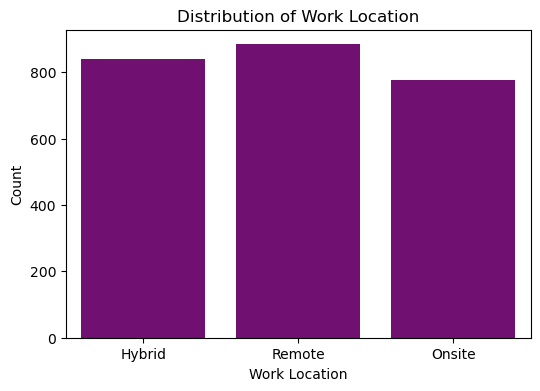

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Work_Location', data=rw, color='purple')
plt.title("Distribution of Work Location")
plt.xlabel("Work Location")
plt.ylabel("Count")
plt.show()

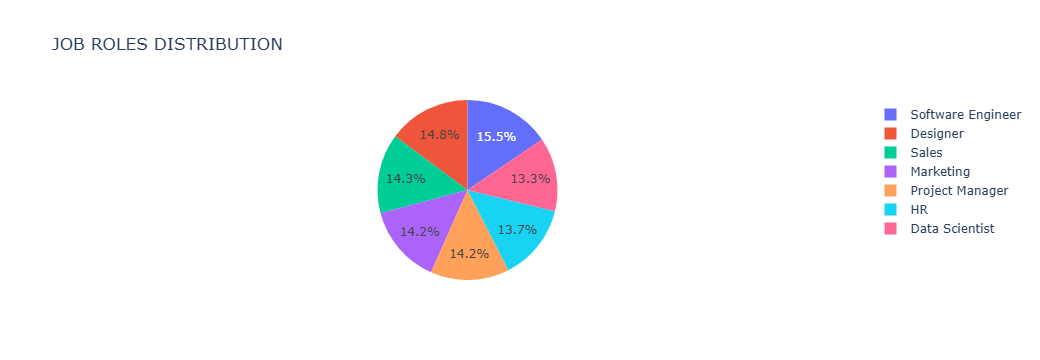

In [67]:
fig = px.pie(rw, names='Job_Role',
             title="JOB ROLES DISTRIBUTION")

fig.show()

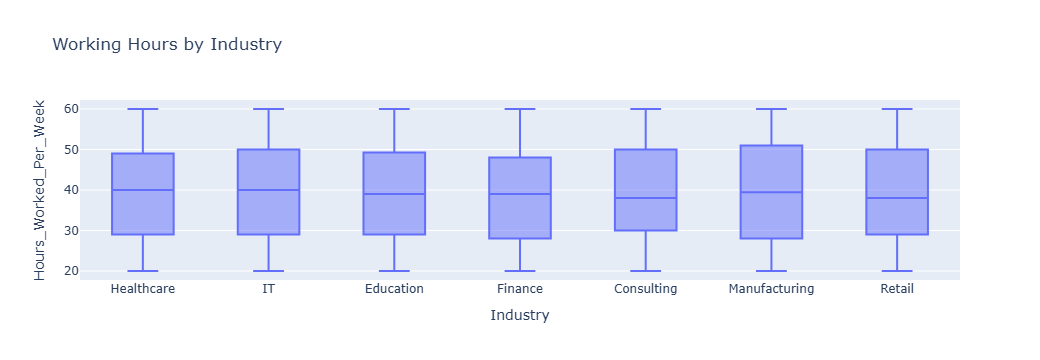

In [34]:
fig = px.box(rw, x='Industry', y='Hours_Worked_Per_Week',
             title="Working Hours by Industry")

fig.show()

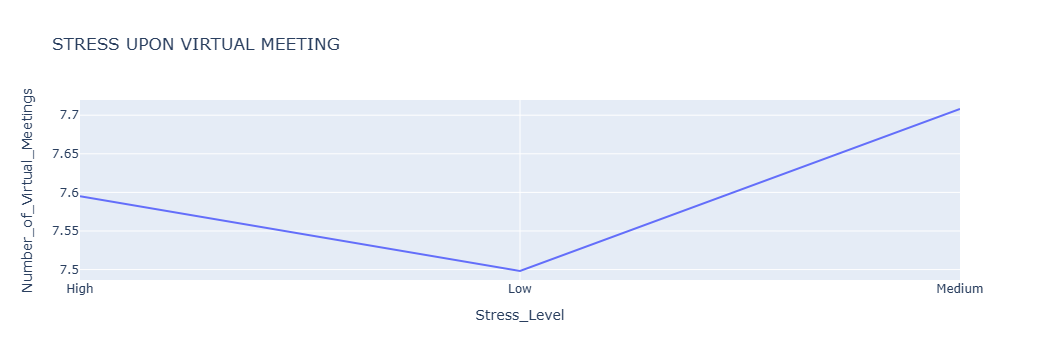

In [101]:
agg_stress= rw.groupby('Stress_Level')['Number_of_Virtual_Meetings'].mean().reset_index()

fig = px.line(agg_stress,
              x='Stress_Level',
              y='Number_of_Virtual_Meetings',
              title="STRESS UPON VIRTUAL MEETING")

fig.show()

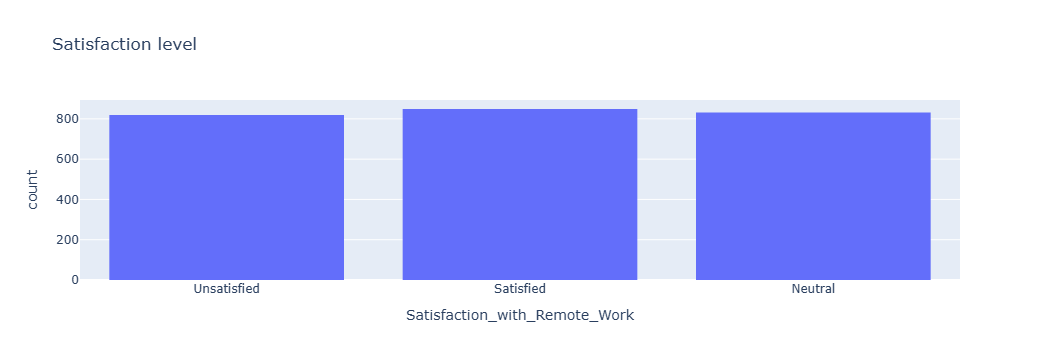

In [90]:
fig = px.histogram(rw,
             x='Satisfaction_with_Remote_Work',
             title="Satisfaction level")
fig.show()

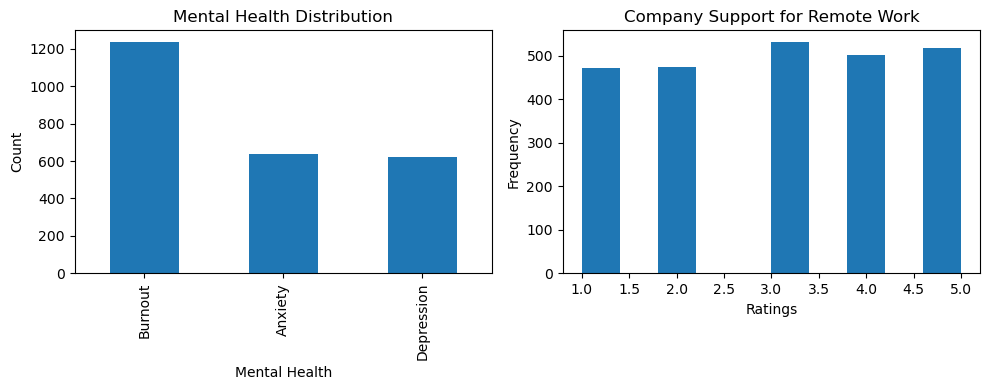

In [97]:
plt.figure(figsize=(10,4))

# Plot 1: Bar plot
plt.subplot(1,2,1)
rw['Mental_Health_Condition'].value_counts().plot(kind='bar')
plt.title("Mental Health Distribution")
plt.xlabel("Mental Health")
plt.ylabel("Count")

# Plot 2: Histogram
plt.subplot(1,2,2)
plt.hist(rw['Company_Support_for_Remote_Work'])
plt.title("Company Support for Remote Work")
plt.xlabel("Ratings")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Insight Generation and Report :

*Remote and hybrid work dominate, indicating a flexible work culture
*Working hours are consistent across industries and age groups
*Stress levels vary significantly by job role and workload intensity Meetings and workload are major contributors to stress
*Mental health directly affects productivity

CONCLUSION:

*The analysis reveals that while working hours are consistent across industries and demographics, stress levels vary depending on job role and workload intensity.
*The organization demonstrates a flexible work environment, with remote and hybrid models widely adopted.
*workload factors such as frequent meetings and job demands play a critical role in influencing employee stress and productivity